# 03 - A network with one hidden layer

Phase 2, part 2.

One neuron can only draw a straight line between the two classes. A hidden layer
lets the model bend that line. Here we ask a simple question:

**does a hidden layer help, and how big should it be?**

We try 3 sizes (4, 16, 64 units) and 2 activations (tanh and relu).
We run every combination **3 times with different seeds**. You will see why.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from ecg.config import Config
from ecg.data import load_split, class_names
from ecg.metrics import report, macro_f1, accuracy, majority_baseline, confusion_matrix
from ecg import plots

from dataclasses import replace
from ecg.train import train, load_results

## 1. One training, to see the shape of it

`train(config)` does everything: load, build the weights, run the epochs, measure,
and write one line into `results/results.csv`.

In [2]:
cfg = Config(classes="NV", output_activation="sigmoid", optimizer="gd",
             hidden_dims=(16,), hidden_activation="tanh", init="he",
             learning_rate=0.1, batch_size=64, epochs=10, seed=1,
             phase="2-demo", note="one shallow run, shown in the notebook")

out = train(cfg, verbose=True, log=False)

epoch 1/10  train loss 0.04039  train mF1 0.9597  dev mF1 0.5206


epoch 2/10  train loss 0.02874  train mF1 0.9709  dev mF1 0.5474


epoch 3/10  train loss 0.02218  train mF1 0.9814  dev mF1 0.6493


epoch 4/10  train loss 0.01796  train mF1 0.9832  dev mF1 0.6485


epoch 5/10  train loss 0.01536  train mF1 0.9856  dev mF1 0.6834


epoch 6/10  train loss 0.01367  train mF1 0.9863  dev mF1 0.689


epoch 7/10  train loss 0.01359  train mF1 0.9855  dev mF1 0.6417


epoch 8/10  train loss 0.01108  train mF1 0.9908  dev mF1 0.7396


epoch 9/10  train loss 0.01038  train mF1 0.9887  dev mF1 0.6767


epoch 10/10  train loss 0.00924  train mF1 0.993  dev mF1 0.738


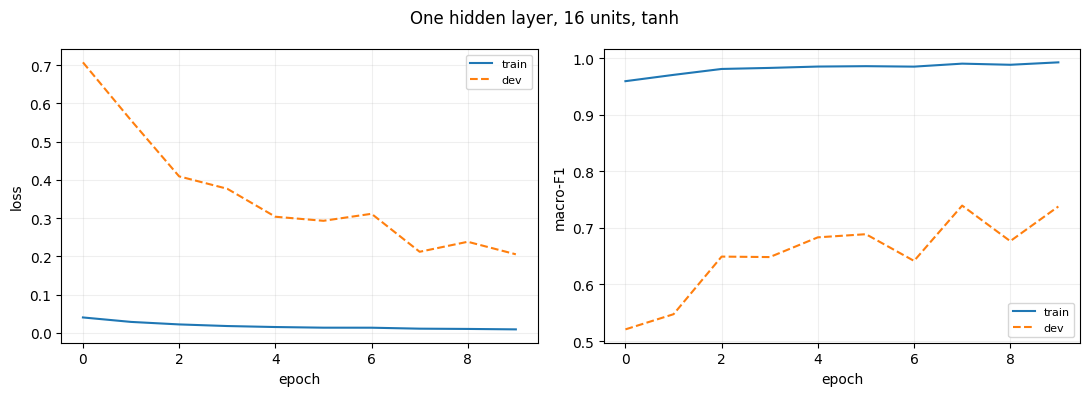

In [3]:
fig = plots.learning_curves(out["history"], title="One hidden layer, 16 units, tanh")
plt.show()

Look at the gap between the two lines on the right plot. Train keeps going up,
dev stops early and stays flat. The model is learning the training patients by
heart. More epochs will not fix that.

## 2. The sweep

The full sweep is 3 sizes x 2 activations x 3 seeds = 18 runs, about 6 minutes.
It was already run, and every result is inside `results/results.csv`.
So here we only read the file.

If you want to run it again, use the loop in the next cell.

In [4]:
# HOW THE SWEEP WAS RUN (it takes about 6 minutes, so it is turned off here)
#
# base = Config(classes="NV", output_activation="sigmoid", optimizer="gd",
#               init="he", learning_rate=0.1, batch_size=64, epochs=30,
#               phase="2", note="shallow sweep")
# for size in [4, 16, 64]:
#     for act in ["tanh", "relu"]:
#         for seed in [1, 2, 3]:
#             train(replace(base, hidden_dims=(size,), hidden_activation=act,
#                           seed=seed), verbose=False)

df = load_results()
sweep = df[df["note"] == "shallow sweep"]
print("runs in the sweep:", len(sweep))

runs in the sweep: 18


In [5]:
table = (sweep.groupby(["hidden_dims", "hidden_activation"])["dev_macro_f1"]
              .agg(["mean", "std", "min", "max"])
              .round(4)
              .sort_values("mean", ascending=False))
print(table.to_string())

                                 mean     std     min     max
hidden_dims hidden_activation                                
16          tanh               0.7305  0.0652  0.6558  0.7759
4           tanh               0.7188  0.0784  0.6363  0.7924
64          tanh               0.7084  0.0462  0.6583  0.7493
4           relu               0.6823  0.0697  0.6062  0.7431
64          relu               0.6722  0.0110  0.6623  0.6841
16          relu               0.6507  0.0334  0.6125  0.6743


## 3. The seeds matter more than the settings

Look at the `min` and `max` columns.

For 4 units with tanh, the worst seed gives about 0.64 and the best gives about
0.79. That is a very big difference, and **nothing changed except the starting
random weights**.

Now compare the `mean` column. The distance between the best setting and the worst
setting is smaller than the distance between two seeds of the same setting.

This is the reason we always run 3 seeds. With only one run per setting we could
"prove" almost anything we want.

saved results/figures/phase2_shallow_sweep.png


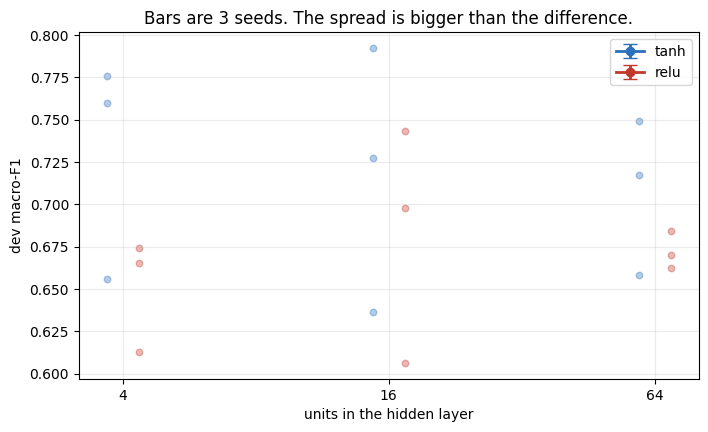

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for act, colour in [("tanh", "#2c6fbb"), ("relu", "#c0392b")]:
    part = sweep[sweep["hidden_activation"] == act]
    g = part.groupby("hidden_dims")["dev_macro_f1"].agg(["mean", "std"])
    g = g.reindex([4, 16, 64])
    ax.errorbar(range(3), g["mean"], yerr=g["std"], marker="o", capsize=5,
                label=act, color=colour, lw=2)
    ax.scatter(np.repeat(range(3), 3) + (0.06 if act == "relu" else -0.06),
               part.sort_values("hidden_dims")["dev_macro_f1"],
               color=colour, alpha=0.35, s=22)
ax.set_xticks(range(3), ["4", "16", "64"])
ax.set_xlabel("units in the hidden layer")
ax.set_ylabel("dev macro-F1")
ax.set_title("Bars are 3 seeds. The spread is bigger than the difference.")
ax.legend()
ax.grid(alpha=0.25)
plots.save(fig, "phase2_shallow_sweep")
plt.show()

## 4. What we learned

- **tanh is better than relu here**, at every size, by about 0.05. This is small but
  it happens every time, so we believe it.
- **The size of the hidden layer changes almost nothing.** 4 units are as good as 64.
- Train macro-F1 is near 0.99 for every single run. So the model is big enough
  already. The problem is not the model, the problem is that we only have **17
  patients** in train. A bigger brain does not help you if you never met enough
  people.